## Precision@K and Mean average precision

In [13]:
from langchain_postgres import PGVector
from dotenv import load_dotenv
import os
import json
import numpy
from langchain_huggingface import HuggingFaceEmbeddings
from tf_idf_module.tf_idf_vectorizer import TFIDFVectorizer
from similarity_module.cosin_sim import cosin_sim
from similarity_module.okapi_bm25 import Bm25Okapi
from tqdm.notebook import tqdm
load_dotenv(override=True)

connection = os.getenv("db_connection_string")

In [14]:
import random

groups = ["ngực","lưng","vai","tay trước","tay sau","chân","mông","bắp chân","bụng"]

patterns = [
    "bài tập cho {}",
    "cách tập {} hiệu quả",
    "tập {} như thế nào",
    "lịch tập {}",
    "tăng cơ {} nhanh",
    "giảm mỡ {}",
    "tập {} tại nhà",
    "bài tập {} với tạ",
    "các lỗi khi tập {}",
    "cách kích hoạt {}",
    "tập {} bao nhiêu lần 1 tuần",
]

mods = ["", " cho nam", " cho nữ", " cho người mới", " nâng cao", " không cần tạ"]

queries = []
for i in range(1, 1001):
    g = random.choice(groups)
    p = random.choice(patterns)
    m = random.choice(mods)

    q = (p.format(g) + m).strip()
    queries.append((f"q{i}", q))

print(queries)

[('q1', 'tập mông bao nhiêu lần 1 tuần cho nam'), ('q2', 'tập ngực tại nhà'), ('q3', 'giảm mỡ tay trước cho nam'), ('q4', 'tập lưng tại nhà cho nam'), ('q5', 'cách tập ngực hiệu quả không cần tạ'), ('q6', 'các lỗi khi tập chân nâng cao'), ('q7', 'giảm mỡ lưng không cần tạ'), ('q8', 'bài tập cho tay trước cho người mới'), ('q9', 'tập bắp chân như thế nào cho nữ'), ('q10', 'bài tập bắp chân với tạ nâng cao'), ('q11', 'tập chân bao nhiêu lần 1 tuần'), ('q12', 'các lỗi khi tập lưng không cần tạ'), ('q13', 'các lỗi khi tập lưng cho nam'), ('q14', 'cách kích hoạt vai cho người mới'), ('q15', 'lịch tập chân cho nữ'), ('q16', 'giảm mỡ bắp chân không cần tạ'), ('q17', 'giảm mỡ lưng cho người mới'), ('q18', 'bài tập chân với tạ cho người mới'), ('q19', 'tăng cơ ngực nhanh không cần tạ'), ('q20', 'tập bụng bao nhiêu lần 1 tuần cho nam'), ('q21', 'cách kích hoạt lưng cho nam'), ('q22', 'tập bụng tại nhà không cần tạ'), ('q23', 'tăng cơ vai nhanh không cần tạ'), ('q24', 'lịch tập tay sau cho nữ'), 

In [16]:
embeddings = HuggingFaceEmbeddings(
    model_name="Qwen/Qwen3-Embedding-0.6B"
)

vector_store = PGVector(
    connection=connection,
    embeddings=embeddings,
    collection_name="fitness_coach_embeddings",
)

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

In [17]:
tfidf_vectorizer = TFIDFVectorizer()
bm25_okapi = Bm25Okapi()

In [18]:
def get_documents(path: str = "data/Knowedge_base_RAG/exercises/exercises/exercises_vn.json"):
    with open(path, "r", encoding="utf-8") as f:
        data = json.loads(f.read())
    return [(d["id"], d["instructions"]["vi"]) for d in data]

In [19]:
tfidf_vectorizer.fit(get_documents())
bm25_okapi.fit(get_documents())

In [20]:
def bm25_okapi_search(query: tuple[str, str], n: int) -> list[str]:
    scores = bm25_okapi.scores(query[1])
    sorted_scores = sorted([(key, scores[key]) for key in scores.keys()], key=lambda x: x[1], reverse=True)
    results = [id for id, score in sorted_scores[:n]]
    return results

def cosin_sim_search(query: tuple[str, str], n: int) -> list[str]:
    query_vec = tfidf_vectorizer.transform([query])
    doc_vecs = tfidf_vectorizer.transform(get_documents())
    scores = cosin_sim(query_vec, doc_vecs)[query[0]]
    sorted_scores = sorted([(key, scores[key]) for key in scores.keys()], key=lambda x: x[1], reverse=True)
    results = [id for id, score in sorted_scores[:n]]
    return results


In [21]:
# define the precision@K calculation function
def precision_at_k_with_query(retrieved_docIDs: list[str], relevant_docIDs: list[str]) -> float:
    retrieved_set = set(retrieved_docIDs)
    relevant_set = set(relevant_docIDs)

    true_positives = len(retrieved_set & relevant_set)
    precision_at_k = true_positives / len(retrieved_docIDs) if retrieved_docIDs else 0

    return precision_at_k

In [ ]:
def recall_at_k_with_query(retrieved_docIDs: list[str], relevant_docIDs: list[str]) -> float:
    retrieved_set = set(retrieved_docIDs)
    relevant_set = set(relevant_docIDs)

    true_positives = len(retrieved_set & relevant_set)
    recall_at_k = true_positives / len(relevant_docIDs) if relevant_docIDs else 0

    return recall_at_k

In [22]:
tfidf_average_precision_results = []
bm25_average_precision_results = []

k=1
for query in tqdm(queries, desc=f"Evaluating query {k}"):
    k+=1
    tfidf_k_results = []
    bm25_k_results = []

    embed_docIDs = [doc.id for doc in vector_store.similarity_search(query[1], 1000)]
    tfidf_docIDs = cosin_sim_search(query, 1000)
    bm25_docIDs = bm25_okapi_search(query, 1000)

    for i in range(1, len(embed_docIDs) + 1):
        #
        tfidf_k_results.append(precision_at_k_with_query(tfidf_docIDs[:i], embed_docIDs[:i]))
        #
        bm25_k_results.append(precision_at_k_with_query(bm25_docIDs[:i], embed_docIDs[:i]))

    tfidf_average_precision_results.append((query[0], sum(tfidf_k_results) / len(tfidf_k_results)))
    bm25_average_precision_results.append((query[0], sum(bm25_k_results) / len(bm25_k_results)))


Evaluating query 1:   0%|          | 0/1000 [00:00<?, ?it/s]

In [ ]:
#average precision across all queries
TFIDF_AP=[(query_id, numpy.mean(tfidf_k_results)) for query_id, tfidf_k_results in tfidf_average_precision_results]
BM25_AP=[(query_id, numpy.mean(bm25_k_results)) for query_id, bm25_k_results in bm25_average_precision_results]


In [ ]:
#mean average precision across all queries
TFIDF_MAP=numpy.mean([tfidf_ap for query_id, tfidf_ap in TFIDF_AP])
BM25_MAP=numpy.mean([bm25_ap for query_id, bm25_ap in BM25_AP])

In [25]:
TFIDF_AP

[('q1', np.float64(0.3949379256495526)),
 ('q2', np.float64(0.45540088107916854)),
 ('q3', np.float64(0.374102747953295)),
 ('q4', np.float64(0.3874135425481059)),
 ('q5', np.float64(0.41601895131940664)),
 ('q6', np.float64(0.4748239418906983)),
 ('q7', np.float64(0.31652639931629994)),
 ('q8', np.float64(0.38690226066228983)),
 ('q9', np.float64(0.40090150070314523)),
 ('q10', np.float64(0.4010187098415035)),
 ('q11', np.float64(0.40529919778555373)),
 ('q12', np.float64(0.3866376639008593)),
 ('q13', np.float64(0.42070819163331485)),
 ('q14', np.float64(0.36855026096529525)),
 ('q15', np.float64(0.37263828939047194)),
 ('q16', np.float64(0.31956911316144787)),
 ('q17', np.float64(0.39486110196771296)),
 ('q18', np.float64(0.33693526654732053)),
 ('q19', np.float64(0.4121330628888984)),
 ('q20', np.float64(0.44749407443333084)),
 ('q21', np.float64(0.415202537326848)),
 ('q22', np.float64(0.4176415691882769)),
 ('q23', np.float64(0.2919794894233909)),
 ('q24', np.float64(0.3726052854

In [26]:
BM25_AP

[('q1', np.float64(0.3918087557221929)),
 ('q2', np.float64(0.44758922604157286)),
 ('q3', np.float64(0.31783164504245837)),
 ('q4', np.float64(0.39304877012691036)),
 ('q5', np.float64(0.42953351594850714)),
 ('q6', np.float64(0.4330834903155274)),
 ('q7', np.float64(0.3673265673759299)),
 ('q8', np.float64(0.33714691720758955)),
 ('q9', np.float64(0.36445352989720886)),
 ('q10', np.float64(0.3994603774760483)),
 ('q11', np.float64(0.3367068108814284)),
 ('q12', np.float64(0.43650212223048823)),
 ('q13', np.float64(0.42285610973932497)),
 ('q14', np.float64(0.362336623850782)),
 ('q15', np.float64(0.32133200151454966)),
 ('q16', np.float64(0.28219982553425416)),
 ('q17', np.float64(0.3939043638134677)),
 ('q18', np.float64(0.34858076884415434)),
 ('q19', np.float64(0.4379052407697761)),
 ('q20', np.float64(0.43966030530764466)),
 ('q21', np.float64(0.40920811910458754)),
 ('q22', np.float64(0.41131370619473273)),
 ('q23', np.float64(0.37031793147993414)),
 ('q24', np.float64(0.3749590

In [27]:
TFIDF_MAP

np.float64(0.39471275632682845)

In [28]:
BM25_MAP

np.float64(0.3821985858783908)

## visualization

In [29]:
from matplotlib import pyplot as plt

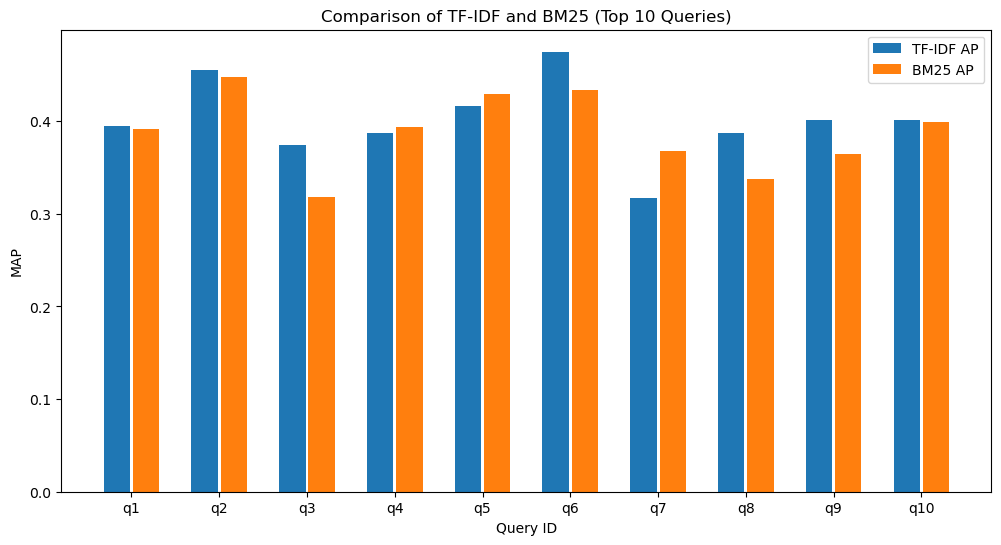

In [35]:
plt.figure(figsize=(12, 6))
labels = [query_id for query_id, _ in TFIDF_AP[:10]]
x = numpy.arange(len(labels))
plt.bar(x=x - 0.5/3, height=[map_value for _, map_value in TFIDF_AP[:10]], width=0.3, label="TF-IDF AP")
plt.bar(x=x + 0.5/3, height=[map_value for _, map_value in BM25_AP[:10]], width=0.3, label="BM25 AP")
plt.xlabel("Query ID")
plt.xticks(x, labels)
plt.ylabel("MAP")
plt.title("Comparison of TF-IDF and BM25 (Top 10 Queries)")
plt.legend()
plt.show()